In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt 

In [2]:
df=pd.read_csv('data.csv')
df.head()

,feature1,feature2,feature3,target
0,-0.570563,1.420342,0.495580,-9.763182
1,-0.990563,0.556965,1.045064,-24.029355
2,-0.674728,0.150617,1.774645,45.616421
3,0.388250,-0.387127,-0.110229,34.135737
4,1.167882,-0.024104,0.145063,86.663647


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   feature1  200 non-null    float64
 1   feature2  200 non-null    float64
 2   feature3  200 non-null    float64
 3   target    200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [4]:
X=df.iloc[:,0:3].values
y=df.iloc[:,-1].values

In [5]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.3, random_state=1)

In [6]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [7]:
y_pred=model.predict(X_test)
residual = y_test - y_pred

# **1. Linear Relationship** 

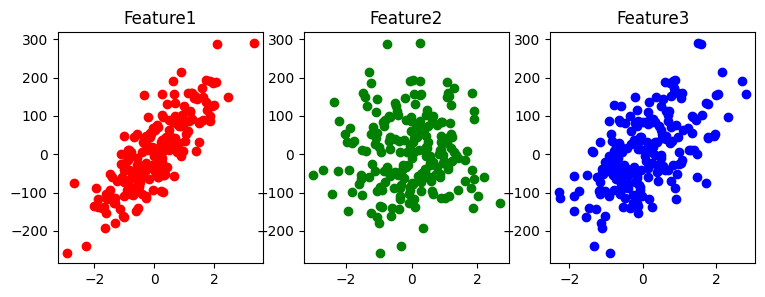

In [9]:
fig, (ax1, ax2, ax3) = plt.subplots(ncols=3, figsize=(9,3))

ax1.scatter(df['feature1'], df['target'], color='red')
ax1.set_title('Feature1')

ax2.scatter(df['feature2'], df['target'], color='green')
ax2.set_title('Feature2')

ax3.scatter(df['feature3'], df['target'], color='blue')
ax3.set_title('Feature3')

plt.show()

# **2. Multicolinearity** 

In [11]:
X_train.shape

(140, 3)

In [12]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif =[]
for i in range(X_train.shape[1]):
    vif.append(variance_inflation_factor(X_train, i))

In [15]:
pd.DataFrame({'vif':vif}, index=['feature1', 'feature2', 'feature3']).T

,feature1,feature2,feature3
vif,1.010326,1.009871,1.01395


<Axes: >

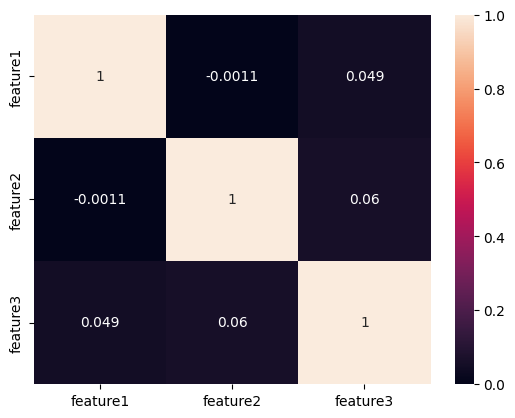

In [16]:
# Another Technique
sns.heatmap(df.iloc[:, 0:3].corr(), annot=True)

# **3. Normality of Residual** 

<Axes: ylabel='Density'>

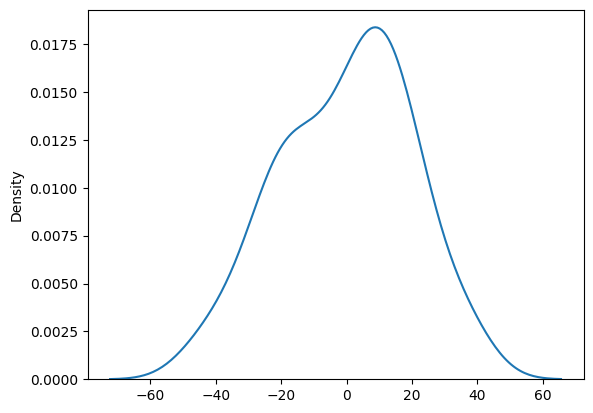

In [17]:
sns.kdeplot(residual)

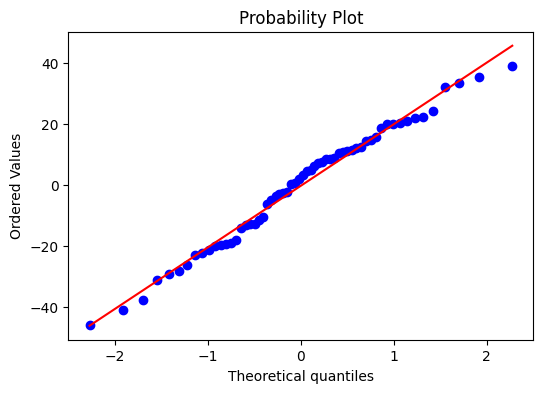

In [18]:
# QQ plot
import scipy as sp 
fig, ax = plt.subplots(figsize=(6,4))
sp.stats.probplot(residual, plot=ax, fit=True)

plt.show()

# **4. Homoscedasticity** 

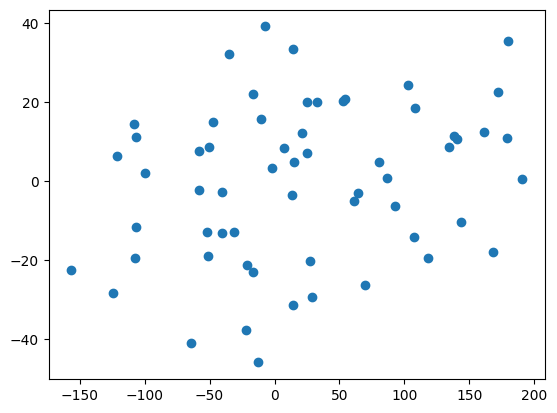

In [19]:
plt.scatter(y_pred, residual)

# **4. Auto Correlation of residual**

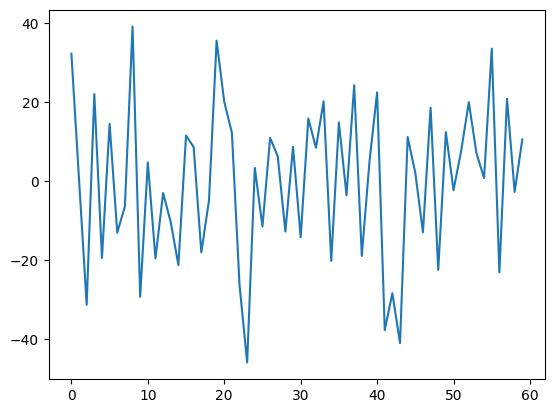

In [20]:
plt.plot(residual)